In [11]:
import os

# Configura la ruta del intérprete de Python
os.environ['PYSPARK_PYTHON'] = r'C:\Users\955\AppData\Local\anaconda3\envs\Pyspark\python.exe'
os.environ['PYSPARK_DRIVER_PYTHON'] = r'C:\Users\955\AppData\Local\anaconda3\envs\Pyspark\python.exe'

In [12]:
# 1. Configuración del entorno y librerías necesarias

from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark import StorageLevel




In [13]:

spark = SparkSession.builder \
    .appName("ExecutorConfiguration") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.instances", "2") \
    .getOrCreate()


spark.sparkContext.setLogLevel("ERROR")  # Reducimos el ruido de los logs

In [14]:
# 3. Carga los datos desde el archivo CSV
df = spark.read.csv("dataset.csv", header=True, inferSchema=True)
df.persist(StorageLevel.MEMORY_AND_DISK)  

# Aplicamos persist que nos ayudan a manténer los datos en memoria y disco para mayor eficiencia

DataFrame[Month: int, Hour: int, DayOfWeek: string, Holiday: string, Temperature: double, Humidity: double, SquareFootage: double, Occupancy: int, HVACUsage: string, LightingUsage: string, RenewableEnergy: double, EnergyConsumption: double]

In [15]:
# 4. Feature Engineering: creamos nuevas variables útiles para mejorar el poder predictivo
#    - IsWeekend: indica si el día es sábado o domingo
#    - IsHolidayOrWeekend: combina días festivos y fines de semana
#    - PeakHour: identifica horas pico de consumo energético
#    - EnergyPerPerson: consumo por persona
#    - Temp_HVAC: interacción entre temperatura y uso de HVAC
df = df.withColumn("IsWeekend", F.when(df.DayOfWeek.isin("Saturday", "Sunday"), 1).otherwise(0))
df = df.withColumn("IsHolidayOrWeekend", F.when((df.Holiday == "Yes") | (df.DayOfWeek.isin("Saturday", "Sunday")), 1).otherwise(0))
df = df.withColumn("PeakHour", F.when(df.Hour.isin([7,8,9,17,18,19]), 1).otherwise(0))  # Ajusta según tus datos
df = df.withColumn("EnergyPerPerson", F.when(df.Occupancy > 0, df.EnergyConsumption / df.Occupancy).otherwise(0))
df = df.withColumn("Temp_HVAC", df.Temperature * F.when(df.HVACUsage == "High", 2).otherwise(1))

In [16]:
# 5. Tratamos los outliers en la variable objetivo (winsorización)
#    - Limitamos los valores extremos de EnergyConsumption al percentil 1 y 99
q_low, q_high = df.approxQuantile("EnergyConsumption", [0.01, 0.99], 0.01)
df = df.withColumn("EnergyConsumption", 
                   F.when(df.EnergyConsumption < q_low, q_low)
                   .when(df.EnergyConsumption > q_high, q_high)
                   .otherwise(df.EnergyConsumption))

In [17]:

# 6. Indexamos y codificamos las variables categóricas
#    - Conviertimos variables categóricas a índices numéricos y luego a vectores one-hot
categorical_cols = ['DayOfWeek', 'Holiday', 'HVACUsage', 'LightingUsage']
indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid='keep') for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]

In [18]:

# 7. Ensamblamos todas las variables en un solo vector de características
#    - Incluye variables numéricas originales y nuevas variables creadas
numeric_cols = [
    'Month', 'Hour', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy',
    'IsWeekend', 'IsHolidayOrWeekend', 'PeakHour', 'EnergyPerPerson', 'Temp_HVAC'
]
assembler_inputs = [col+"_vec" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

In [19]:
# 8. Escalamos las variables para mejorar el rendimiento de los modelos lineales y de árboles
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

In [20]:

# 9. Dividimos el dataset en entrenamiento (80%) y prueba (20%)
train, test = df.randomSplit([0.8, 0.2], seed=42)
train.persist(StorageLevel.MEMORY_AND_DISK)
test.persist(StorageLevel.MEMORY_AND_DISK)

DataFrame[Month: int, Hour: int, DayOfWeek: string, Holiday: string, Temperature: double, Humidity: double, SquareFootage: double, Occupancy: int, HVACUsage: string, LightingUsage: string, RenewableEnergy: double, EnergyConsumption: double, IsWeekend: int, IsHolidayOrWeekend: int, PeakHour: int, EnergyPerPerson: double, Temp_HVAC: double]

In [ ]:
# 10. Definimos los modelos a entrenar
#     - Linear Regression: modelo lineal simple
#     - Random Forest: modelo de árboles de decisión en conjunto
lr = LinearRegression(featuresCol="scaledFeatures", labelCol="EnergyConsumption", regParam=0.01)
rf = RandomForestRegressor(featuresCol="scaledFeatures", labelCol="EnergyConsumption", numTrees=100)


In [22]:
# 11. Creamos los pipelines para cada modelo
#     - El pipeline incluye indexación, codificación, ensamblado, escalado y el modelo
stages = indexers + encoders + [assembler, scaler]
pipeline_lr = Pipeline(stages=stages + [lr])
pipeline_rf = Pipeline(stages=stages + [rf])


In [23]:
# 12. Ajustamos de hiperparámetros para Random Forest usando validación cruzada
#     - Prueba distintos valores de número de árboles y profundidad máxima
paramGrid_rf = (ParamGridBuilder()
                .addGrid(rf.numTrees, [50, 100])
                .addGrid(rf.maxDepth, [5, 10])
                .build())
evaluator = RegressionEvaluator(labelCol="EnergyConsumption", predictionCol="prediction", metricName="rmse")
cv_rf = CrossValidator(estimator=pipeline_rf,
                       estimatorParamMaps=paramGrid_rf,
                       evaluator=evaluator,
                       numFolds=3)

In [24]:
# 13. Entrenamos los modelos
#     - Ajustamos los modelos a los datos de entrenamiento
model_lr = pipeline_lr.fit(train)
model_rf = cv_rf.fit(train)  # Random Forest con validación cruzada


In [25]:

# 14. Realizamos predicciones en el set de prueba
pred_lr = model_lr.transform(test)
pred_rf = model_rf.transform(test)



In [26]:

# 15. Evalúamos los modelos con RMSE, MAE y R2
def print_metrics(model_name, predictions):
    rmse = evaluator.evaluate(predictions, {evaluator.metricName: "rmse"})
    mae = evaluator.evaluate(predictions, {evaluator.metricName: "mae"})
    r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})
    print(f"{model_name}:\n RMSE: {rmse:.4f}\n MAE: {mae:.4f}\n R2: {r2:.4f}\n")


print("Resultados de los modelos mejorados:\n")
print_metrics("Linear Regression", pred_lr)
print_metrics("Random Forest (CrossVal)", pred_rf)

Resultados de los modelos mejorados:

Linear Regression:
 RMSE: 7.8147
 MAE: 6.1730
 R2: 0.3123

Random Forest (CrossVal):
 RMSE: 6.7039
 MAE: 5.1361
 R2: 0.4939



In [27]:
pip install --upgrade numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [28]:
import matplotlib.pyplot as plt

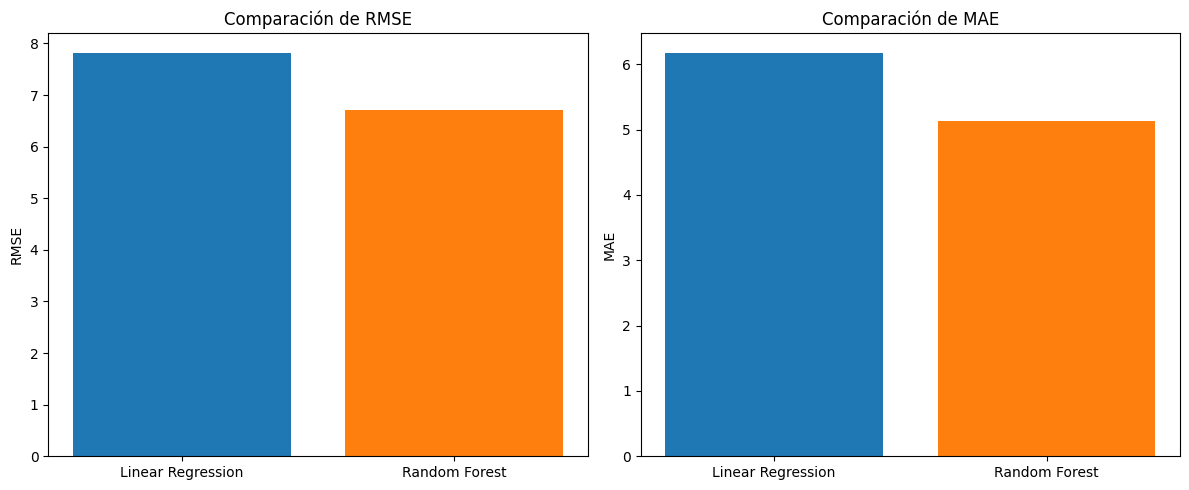

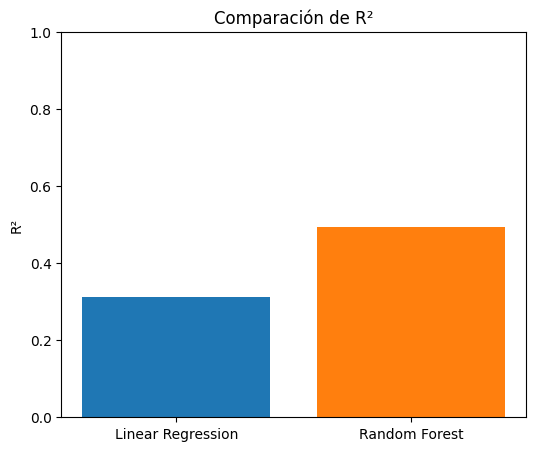

In [29]:

from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt

# Define los evaluadores (opción 1: uno para cada métrica)
evaluator_rmse = RegressionEvaluator(labelCol="EnergyConsumption", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="EnergyConsumption", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="EnergyConsumption", predictionCol="prediction", metricName="r2")

# Otra opción (opción 2): usar solo un evaluador y cambiar la métrica al evaluar
# evaluator = RegressionEvaluator(labelCol="EnergyConsumption", predictionCol="prediction")

# Calcula las métricas
modelos = ["Linear Regression", "Random Forest"]
rmse = [evaluator_rmse.evaluate(pred_lr), evaluator_rmse.evaluate(pred_rf)]
mae = [evaluator_mae.evaluate(pred_lr), evaluator_mae.evaluate(pred_rf)]
r2 = [evaluator_r2.evaluate(pred_lr), evaluator_r2.evaluate(pred_rf)]

# Gráfico de barras para RMSE y MAE
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].bar(modelos, rmse, color=['#1f77b4', '#ff7f0e'])
ax[0].set_title("Comparación de RMSE")
ax[0].set_ylabel("RMSE")
ax[1].bar(modelos, mae, color=['#1f77b4', '#ff7f0e'])
ax[1].set_title("Comparación de MAE")
ax[1].set_ylabel("MAE")
plt.tight_layout()
plt.show()

# Gráfico de barras para R²
plt.figure(figsize=(6,5))
plt.bar(modelos, r2, color=['#1f77b4', '#ff7f0e'])
plt.title("Comparación de R²")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.show()



RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error)
RMSE:

Random Forest: 6.70

Linear Regression: 7.81

Diferencia: El modelo de Random Forest tiene un error aproximadamente 1.1 unidades menor.

MAE:

Random Forest: 5.14

Linear Regression: 6.17

Diferencia: El error absoluto promedio de Random Forest es casi 1 unidad menor.

Al analizar las metricas el modelo Random Forest nos arroja mejores metricas ademas de la posibilidad de poder  realizar un Feature Engineering y ponderar las variables frente su importancia con la variable objetivo.

In [30]:
# 16. Analizamos la importancia de las variables en el mejor modelo de árboles
#     - Lo que buscamos con esto es identificar las variables más relevantes
rf_best_model = model_rf.bestModel.stages[-1]
importances = rf_best_model.featureImportances
print("Importancia de variables (Random Forest):")
for idx, imp in enumerate(importances):
    print(f"Feature {idx}: {imp:.4f}")

Importancia de variables (Random Forest):
Feature 0: 0.0050
Feature 1: 0.0057
Feature 2: 0.0051
Feature 3: 0.0035
Feature 4: 0.0047
Feature 5: 0.0053
Feature 6: 0.0055
Feature 7: 0.0047
Feature 8: 0.0042
Feature 9: 0.0065
Feature 10: 0.0055
Feature 11: 0.0051
Feature 12: 0.0053
Feature 13: 0.0322
Feature 14: 0.0352
Feature 15: 0.2229
Feature 16: 0.0428
Feature 17: 0.0430
Feature 18: 0.1117
Feature 19: 0.0460
Feature 20: 0.0045
Feature 21: 0.0047
Feature 22: 0.0055
Feature 23: 0.1900
Feature 24: 0.1952


In [31]:
# 17. Libera recursos de memoria
train.unpersist()
test.unpersist()


DataFrame[Month: int, Hour: int, DayOfWeek: string, Holiday: string, Temperature: double, Humidity: double, SquareFootage: double, Occupancy: int, HVACUsage: string, LightingUsage: string, RenewableEnergy: double, EnergyConsumption: double, IsWeekend: int, IsHolidayOrWeekend: int, PeakHour: int, EnergyPerPerson: double, Temp_HVAC: double]